

Mean Values for each emotion:
--------------------------------------------------
          EmoAct  EmoVal  EmoDom  Count
Angry      5.090   2.648   5.244  22603
Contempt   4.630   3.230   4.850   5680
Disgust    4.587   3.169   4.742   2980
Fear       4.162   3.733   4.075   2125
Happy      4.552   4.883   4.602  44440
Neutral    3.857   3.906   4.143  62081
Sad        3.427   3.070   3.794  15431
Surprise   4.821   4.258   4.803   6357


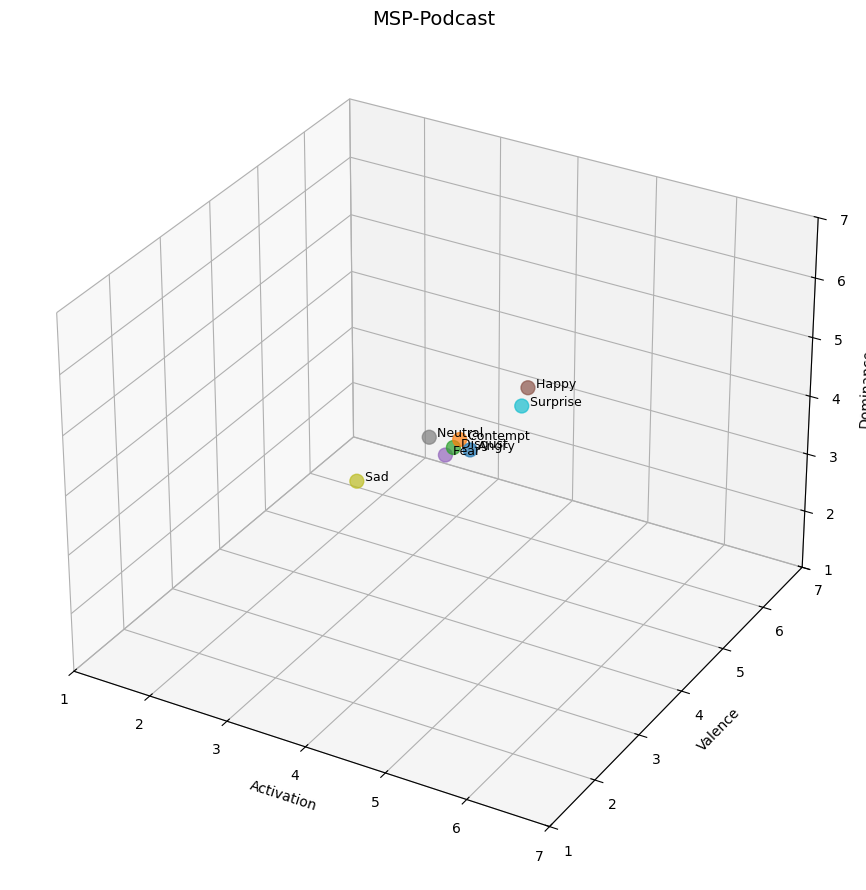

In [ ]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('data/msp_labels_consensus.csv')

# Exclude 'X' and 'O' from EmoClass
df_filtered = df[~df['EmoClass'].isin(['X', 'O'])]

# Group by EmoClass and calculate the mean for EmoAct, EmoVal, and EmoDom
emotion_stats = df_filtered.groupby('EmoClass')[['EmoAct', 'EmoVal', 'EmoDom']].agg(['mean', 'count']).round(3)

# Flatten the column names for better readability
emotion_stats.columns = ['_'.join(col).strip() for col in emotion_stats.columns]

# Summary
summary_df = df_filtered.groupby('EmoClass')[['EmoAct', 'EmoVal', 'EmoDom']].mean().round(3)
summary_df['Count'] = df_filtered.groupby('EmoClass').size()

# Create emotion name mapping
emotion_names = {
    'A': 'Angry',
    'S': 'Sad', 
    'H': 'Happy',
    'U': 'Surprise',
    'F': 'Fear',
    'D': 'Disgust',
    'C': 'Contempt',
    'N': 'Neutral'
}

# Create new index with emotion names in parentheses
new_index = [emotion_names[emo] for emo in summary_df.index]
summary_df.index = new_index
summary_df.to_csv('data/msp_emotion_summary.csv')
print("\n\nMean Values for each emotion:")
print('-'*50)
print(summary_df)

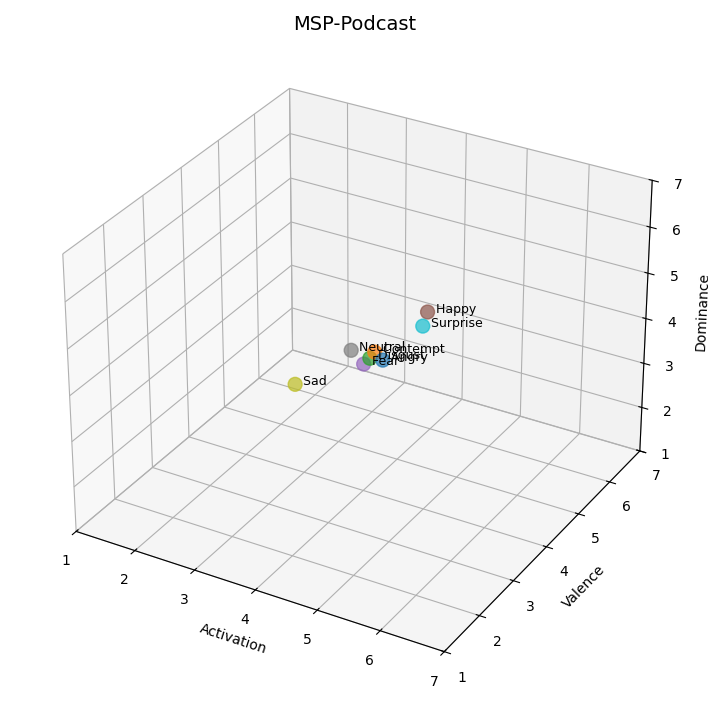

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd

summary_df = pd.read_csv('data/msp_emotion_summary.csv', index_col=0)

# Create 3D plot
cm = 1/2.54
fig = plt.figure(figsize=(18*cm, 18*cm))
ax = fig.add_subplot(111, projection='3d')

# Extract coordinates (excluding Count column)
x = summary_df['EmoAct']
y = summary_df['EmoVal'] 
z = summary_df['EmoDom']

# Create scatter plot
scatter = ax.scatter(x, y, z, s=100, c=range(len(summary_df)), cmap='tab10', alpha=0.7)

# Add labels for each point
for i, emotion in enumerate(summary_df.index):
    ax.text(x.iloc[i], y.iloc[i], z.iloc[i], f'  {emotion}', fontsize=9)

# Set axis labels and limits
ax.set_xlabel('Activation')
ax.set_ylabel('Valence')
ax.set_zlabel('Dominance')
ax.set_xlim(1, 7)
ax.set_ylim(1, 7)
ax.set_zlim(1, 7)

# Set title
ax.set_title('MSP-Podcast', fontsize=14)

plt.tight_layout()
plt.show()